Loading Test Data from: c:\Users\DELL\Desktop\Project\Real-Estate-Intelligence-System\data\processed\test_engineered.csv
Loading Saved Model Artifact from: c:\Users\DELL\Desktop\Project\Real-Estate-Intelligence-System\models\property_price_model.pkl

             MODEL COMPARISON SUMMARY
                 Model  R² (Log Scale)    MAE (PKR)  MAPE (%)
     Gradient Boosting        0.841432 2.108204e+07 30.338269
Hist Gradient Boosting        0.830420 2.149985e+07 32.877392
         Random Forest        0.838329 2.089858e+07 29.954386
     Weighted Ensemble        0.844328 2.059720e+07 30.266006

         PERFORMANCE BREAKDOWN BY PRICE TIER
            Avg_Actual_PKR       MAE_PKR   MAPE_Pct  Sample_Count
Price_Tier                                                       
Budget        1.344063e+07  4.839212e+06  43.738453           209
Mid-Range     3.747681e+07  7.698574e+06  20.320982           207
Luxury        1.470439e+08  4.968712e+07  26.572731           205


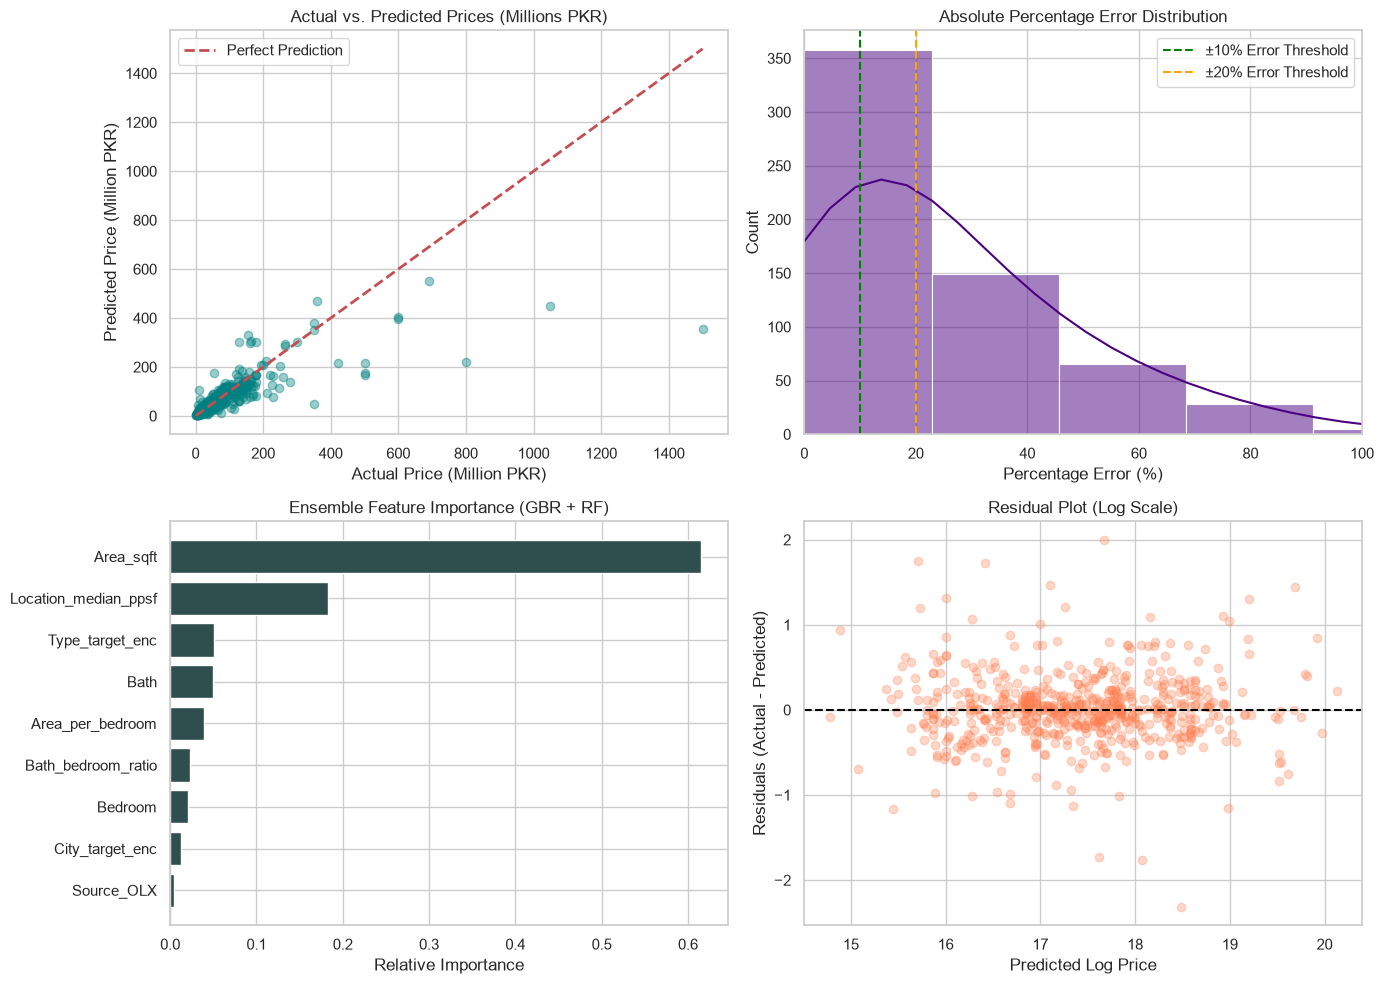

In [1]:
# SEPARATE EVALUATION SCRIPT
# ==========================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

# ------------------------------------------
# 1. Locate Project Root & Load Data / Model
# ------------------------------------------
current_dir = os.getcwd()
while not os.path.exists(os.path.join(current_dir, "data")):
    parent_dir = os.path.dirname(current_dir)
    if parent_dir == current_dir:
        raise FileNotFoundError("Could not locate project root directory!")
    current_dir = parent_dir

PROJECT_ROOT = current_dir

# Paths
TEST_CSV = os.path.join(PROJECT_ROOT, "data", "processed", "test_engineered.csv")
MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "property_price_model.pkl")

# Load Test Data & Saved Model Artifact
print(f"Loading Test Data from: {TEST_CSV}")
test_df = pd.read_csv(TEST_CSV)

print(f"Loading Saved Model Artifact from: {MODEL_PATH}")
artifact = joblib.load(MODEL_PATH)

# Reconstruct Model Objects & Parameters
m_gbr = artifact["gbr"]
m_hgbr = artifact["hgbr"]
m_rf = artifact["rf"]
FEATURES = artifact["features"]
weights = artifact["weights"]  # [0.50, 0.30, 0.20]

# Prepare Test Sets
X_test = test_df[FEATURES]
y_test = test_df["Log_price"]
actual_test_pkr = test_df["Price_pkr"]

# ------------------------------------------
# 2. Compute Individual & Ensemble Predictions
# ------------------------------------------
preds_gbr_log = m_gbr.predict(X_test)
preds_hgbr_log = m_hgbr.predict(X_test)
preds_rf_log = m_rf.predict(X_test)

preds_gbr = np.exp(preds_gbr_log)
preds_hgbr = np.exp(preds_hgbr_log)
preds_rf = np.exp(preds_rf_log)

# Weighted Ensemble Prediction
test_preds_log = (
    (weights[0] * preds_gbr_log)
    + (weights[1] * preds_hgbr_log)
    + (weights[2] * preds_rf_log)
)
test_preds_pkr = np.exp(test_preds_log)

# Overall Accuracy Metrics
r2 = r2_score(y_test, test_preds_log)
mae = mean_absolute_error(actual_test_pkr, test_preds_pkr)


def calc_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


mape = calc_mape(actual_test_pkr, test_preds_pkr)

# ------------------------------------------
# 3. Model Comparison Table
# ------------------------------------------
model_perf = pd.DataFrame(
    {
        "Model": [
            "Gradient Boosting",
            "Hist Gradient Boosting",
            "Random Forest",
            "Weighted Ensemble",
        ],
        "R² (Log Scale)": [
            r2_score(y_test, preds_gbr_log),
            r2_score(y_test, preds_hgbr_log),
            r2_score(y_test, preds_rf_log),
            r2,
        ],
        "MAE (PKR)": [
            mean_absolute_error(actual_test_pkr, preds_gbr),
            mean_absolute_error(actual_test_pkr, preds_hgbr),
            mean_absolute_error(actual_test_pkr, preds_rf),
            mae,
        ],
        "MAPE (%)": [
            calc_mape(actual_test_pkr, preds_gbr),
            calc_mape(actual_test_pkr, preds_hgbr),
            calc_mape(actual_test_pkr, preds_rf),
            mape,
        ],
    }
)

print("\n" + "=" * 65)
print("             MODEL COMPARISON SUMMARY")
print("=" * 65)
print(model_perf.to_string(index=False))
print("=" * 65)

# ------------------------------------------
# 4. Performance Breakdown by Price Tier
# ------------------------------------------
eval_df = pd.DataFrame(
    {
        "Actual_PKR": actual_test_pkr,
        "Predicted_PKR": test_preds_pkr,
        "Abs_Error_PKR": np.abs(actual_test_pkr - test_preds_pkr),
        "Pct_Error": np.abs(actual_test_pkr - test_preds_pkr)
        / actual_test_pkr
        * 100,
    }
)

eval_df["Price_Tier"] = pd.qcut(
    eval_df["Actual_PKR"], q=3, labels=["Budget", "Mid-Range", "Luxury"]
)

tier_summary = eval_df.groupby("Price_Tier", observed=True).agg(
    Avg_Actual_PKR=("Actual_PKR", "mean"),
    MAE_PKR=("Abs_Error_PKR", "mean"),
    MAPE_Pct=("Pct_Error", "mean"),
    Sample_Count=("Actual_PKR", "count"),
)

print("\n" + "=" * 65)
print("         PERFORMANCE BREAKDOWN BY PRICE TIER")
print("=" * 65)
print(tier_summary.to_string())
print("=" * 65)

# ------------------------------------------
# 5. Visualizations
# ------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot A: Actual vs Predicted
axes[0, 0].scatter(
    actual_test_pkr / 1e6, test_preds_pkr / 1e6, alpha=0.4, color="teal"
)
max_val = max(actual_test_pkr.max(), test_preds_pkr.max()) / 1e6
axes[0, 0].plot([0, max_val], [0, max_val], "r--", lw=2, label="Perfect Prediction")
axes[0, 0].set_title("Actual vs. Predicted Prices (Millions PKR)")
axes[0, 0].set_xlabel("Actual Price (Million PKR)")
axes[0, 0].set_ylabel("Predicted Price (Million PKR)")
axes[0, 0].legend()

# Plot B: Error Distribution
sns.histplot(eval_df["Pct_Error"], kde=True, ax=axes[0, 1], color="indigo", bins=40)
axes[0, 1].axvline(
    10, color="green", linestyle="--", label="±10% Error Threshold"
)
axes[0, 1].axvline(
    20, color="orange", linestyle="--", label="±20% Error Threshold"
)
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_title("Absolute Percentage Error Distribution")
axes[0, 1].set_xlabel("Percentage Error (%)")
axes[0, 1].legend()

# Plot C: Feature Importance
gbr_imp = m_gbr.feature_importances_
rf_imp = m_rf.feature_importances_
avg_imp = (0.6 * gbr_imp) + (0.4 * rf_imp)

imp_df = (
    pd.DataFrame({"Feature": FEATURES, "Importance": avg_imp})
    .sort_values(by="Importance", ascending=True)
)

axes[1, 0].barh(imp_df["Feature"], imp_df["Importance"], color="darkslategrey")
axes[1, 0].set_title("Ensemble Feature Importance (GBR + RF)")
axes[1, 0].set_xlabel("Relative Importance")

# Plot D: Residuals
residuals_log = y_test - test_preds_log
axes[1, 1].scatter(test_preds_log, residuals_log, alpha=0.3, color="coral")
axes[1, 1].axhline(0, color="black", linestyle="--", lw=1.5)
axes[1, 1].set_title("Residual Plot (Log Scale)")
axes[1, 1].set_xlabel("Predicted Log Price")
axes[1, 1].set_ylabel("Residuals (Actual - Predicted)")

plt.tight_layout()
plt.show()